In [1]:
import math
from utility import fit
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
# from rkan.torch import PadeRKAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from datetime import datetime
from tqdm import tqdm
from torch.optim import LBFGS
import torch.nn as nn
################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
best_params_CA = {
    "depth": 7,
    "neurons_layer_0": 165,
    "neurons_layer_1": 50,
    "neurons_layer_2": 70,
    "neurons_layer_3": 115,
    "neurons_layer_4": 135,
    "neurons_layer_5": 65,
    "neurons_layer_6": 200,
    
    "orders1_layer_0": 6,
    "orders1_layer_1": 5,
    "orders1_layer_2": 5,    
    "orders1_layer_3": 4,
    "orders1_layer_4": 3,
    "orders1_layer_5": 5,
    "orders1_layer_6": 4,  
    
    "orders2_layer_0": 4,
    "orders2_layer_1": 2,
    "orders2_layer_2": 5,
    "orders2_layer_3": 3,
    "orders2_layer_4": 4,
    "orders2_layer_5": 3,
    "orders2_layer_6": 3,    
}

In [3]:
def shifted_jacobi_polynomial(x, n, alpha, beta, zeta, a, b, backend):
    if n == 1:
        return (
            alpha - beta + (alpha + beta + 2) * (2 * x**zeta - a - b) / (b - a)
        ) / 2
    elif n == 2:
        return (
            ((alpha + 1) * (alpha + 2)) / 2
            + (
                (alpha + 2)
                * (3 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1)
            )
            / 2
            + (
                (3 + alpha + beta)
                * (4 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 2
            )
            / 8
        )
    elif n == 3:
        return (
            ((alpha + 1) * (alpha + 2) * (3 + alpha)) / 6
            + (
                (alpha + 2)
                * (3 + alpha)
                * (4 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1)
            )
            / 4
            + (
                (3 + alpha)
                * (4 + alpha + beta)
                * (5 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 2
            )
            / 8
            + (
                (4 + alpha + beta)
                * (5 + alpha + beta)
                * (6 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 3
            )
            / 48
        )
    elif n == 4:
        return (
            ((alpha + 1) * (alpha + 2) * (3 + alpha) * (4 + alpha)) / 24
            + (
                (alpha + 2)
                * (3 + alpha)
                * (4 + alpha)
                * (5 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1)
            )
            / 12
            + (
                (3 + alpha)
                * (4 + alpha)
                * (5 + alpha + beta)
                * (6 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 2
            )
            / 16
            + (
                (4 + alpha)
                * (5 + alpha + beta)
                * (6 + alpha + beta)
                * (7 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 3
            )
            / 48
            + (
                (5 + alpha + beta)
                * (6 + alpha + beta)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 4
            )
            / 384
        )
    elif n == 5:
        return (
            ((alpha + 1) * (alpha + 2) * (alpha + 3) * (alpha + 4) * (alpha + 5)) / 120
            + (
                (alpha + 2)
                * (alpha + 3)
                * (alpha + 4)
                * (alpha + 5)
                * (6 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1)
            )
            / 48
            + (
                (alpha + 3)
                * (alpha + 4)
                * (alpha + 5)
                * (6 + alpha + beta)
                * (7 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 2
            )
            / 48
            + (
                (alpha + 4)
                * (alpha + 5)
                * (6 + alpha + beta)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 3
            )
            / 96
            + (
                (alpha + 5)
                * (6 + alpha + beta)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * (9 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 4
            )
            / 384
            + (
                (6 + alpha + beta)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * (9 + alpha + beta)
                * (10 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 5
            )
            / 3840
        )
    elif n == 6:
        return (
            (
                (alpha + 1)
                * (alpha + 2)
                * (alpha + 3)
                * (alpha + 4)
                * (alpha + 5)
                * (6 + alpha)
            )
            / 720
            + (
                (alpha + 2)
                * (alpha + 3)
                * (alpha + 4)
                * (alpha + 5)
                * (6 + alpha)
                * (7 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1)
            )
            / 240
            + (
                (alpha + 3)
                * (alpha + 4)
                * (alpha + 5)
                * (6 + alpha)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 2
            )
            / 192
            + (
                (alpha + 4)
                * (alpha + 5)
                * (6 + alpha)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * (9 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 3
            )
            / 288
            + (
                (alpha + 5)
                * (6 + alpha)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * (9 + alpha + beta)
                * (10 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 4
            )
            / 768
            + (
                (6 + alpha)
                * (7 + alpha + beta)
                * (8 + alpha + beta)
                * (9 + alpha + beta)
                * (10 + alpha + beta)
                * (11 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 5
            )
            / 3840
            + (
                (7 + alpha + beta)
                * (8 + alpha + beta)
                * (9 + alpha + beta)
                * (10 + alpha + beta)
                * (11 + alpha + beta)
                * (12 + alpha + beta)
                * ((2 * x**zeta - a - b) / (b - a) - 1) ** 6
            )
            / 46080
        )
    elif n > 6:
        raise ValueError(
            f"The current implementation supports a maximum degree of 6, but you entered {n}. Higher degrees may lead to numerical instabilities, overfitting, and increased computational complexity. Please consider using a lower degree."
        )
    elif n <= 0:
        raise ValueError(
            "Degrees must be positive. Zero or Negative degrees are not allowed."
        )


In [4]:
class PadeRKAN(nn.Module):
    def __init__(self, degree_p, degree_q):
        """
        Initialize the PadeRKAN module.

        Args:
            degree_p (int): Degree of the P polynomial.
            degree_q (int): Degree of the Q polynomial.
        """
        super(PadeRKAN, self).__init__()

        if not 0 < degree_p < 7 or not 0 < degree_q < 7:
            raise ValueError('Both degree_p and degree_q must be between one and six (inclusive).')

        self.degree_p = degree_p
        self.degree_q = degree_q

        # Define the trainable parameters for the P polynomial
        self.alpha_p = nn.Parameter(torch.ones(1))
        self.beta_p = nn.Parameter(torch.ones(1))
        self.zeta_p = nn.Parameter(torch.zeros(1))
        self.w_p = nn.Parameter(torch.ones(self.degree_p))

        # Define the trainable parameters for the Q polynomial
        self.alpha_q = nn.Parameter(torch.ones(1))
        self.beta_q = nn.Parameter(torch.ones(1))
        self.zeta_q = nn.Parameter(torch.zeros(1))
        self.w_q = nn.Parameter(torch.ones(self.degree_q))

    def forward(self, inputs):
        """
        Forward pass of the PadeRKAN module.

        Args:
            inputs (Tensor): Input tensor.

        Returns:
            Tensor: Output tensor after applying the Pade rational function.
        """
        # Normalize parameters for the P polynomial
        normalized_alpha_p = F.elu(self.alpha_p, 1)
        normalized_beta_p = F.elu(self.beta_p, 1)
        normalized_zeta_p = torch.sigmoid(self.zeta_p)

        # Normalize parameters for the Q polynomial
        normalized_alpha_q = F.elu(self.alpha_q, 1)
        normalized_beta_q = F.elu(self.beta_q, 1)
        normalized_zeta_q = torch.sigmoid(self.zeta_q)

        # Normalize inputs
        normalized_inputs = torch.sigmoid(inputs)

        # Calculate the P polynomial
        p = self.w_p[0] + self.w_p[1] * normalized_inputs
        for deg in range(2, self.degree_p):
            p += self.w_p[deg] * shifted_jacobi_polynomial(
                normalized_inputs,
                deg,
                normalized_alpha_p,
                normalized_beta_p,
                normalized_zeta_p,
                0,
                1,
                backend=torch
            )

        # Calculate the Q polynomial
        q = self.w_q[0] + self.w_q[1] * normalized_inputs
        for deg in range(2, self.degree_q):
            q += self.w_q[deg] * shifted_jacobi_polynomial(
                normalized_inputs,
                deg,
                normalized_alpha_q,
                normalized_beta_q,
                normalized_zeta_q,
                0,
                1,
                backend=torch
            )

        # Return the Pade rational function
        return p / q

In [5]:
class fKAN(nn.Module):
    def __init__(self, layers, orders1, orders2):
        super(fKAN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                self.layers.append(PadeRKAN(orders1[i], orders2[i]))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [6]:
EPOCHS = 100

DATA = 'CA'

data = pd.read_csv("/home/data3/Ali/Code/KAN/Afzal/DATA/%s.csv" % DATA)

data.fillna(0, inplace=True)
y = data["target_label"].values
data.drop("target_label", axis=1, inplace=True)
X = data.values.astype(np.float32)

if y.dtype == "object":
    label_encoder = LabelEncoder()
    y = torch.tensor(label_encoder.fit_transform(y))
else:
    y = torch.tensor(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train)).to(device)
X_valid = torch.tensor(scaler.transform(X_valid)).to(device)
X_test = torch.tensor(scaler.transform(X_test)).to(device)

y_train = torch.nn.functional.one_hot(y_train.long(), num_classes=2).to(device).float()
y_valid = torch.nn.functional.one_hot(y_valid.long(), num_classes=2).to(device).float()
y_test = torch.nn.functional.one_hot(y_test.long(), num_classes=2).to(device).float()

input_shape = X_train.shape[1]
output_shape = y_train.shape[1]

dataset = {
"train_input": X_train,
"train_label": y_train,
"test_input": X_valid,
"test_label": y_valid,
}

best_params = best_params_CA
print('best_params:', best_params)

depth = best_params["depth"]
width = [best_params[f"neurons_layer_{i}"] for i in range(depth)]
width = [input_shape] + width + [output_shape]
orders1 = [best_params[f"orders1_layer_{i}"] for i in range(depth)]
orders2 = [best_params[f"orders2_layer_{i}"] for i in range(depth)]

model = fKAN(width, orders1, orders2).to(device)
history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

y_score = model(X_test).cpu()
y_pred = (y_score > 0.5).int()


print(classification_report(y_test.cpu(), y_pred, target_names=label_encoder.classes_))
print("ROC-AUC: %.4f" % roc_auc_score(y_test.cpu(), y_pred))

best_params: {'depth': 7, 'neurons_layer_0': 165, 'neurons_layer_1': 50, 'neurons_layer_2': 70, 'neurons_layer_3': 115, 'neurons_layer_4': 135, 'neurons_layer_5': 65, 'neurons_layer_6': 200, 'orders1_layer_0': 6, 'orders1_layer_1': 5, 'orders1_layer_2': 5, 'orders1_layer_3': 4, 'orders1_layer_4': 3, 'orders1_layer_5': 5, 'orders1_layer_6': 4, 'orders2_layer_0': 4, 'orders2_layer_1': 2, 'orders2_layer_2': 5, 'orders2_layer_3': 3, 'orders2_layer_4': 4, 'orders2_layer_5': 3, 'orders2_layer_6': 3}


| train_loss: -0.00e+00 | test_loss: 2.07e+00 : 100%|█████████████| 100/100 [00:52<00:00,  1.92it/s]

              precision    recall  f1-score   support

           +       0.85      0.71      0.77        77
           -       0.82      0.86      0.84        77

   micro avg       0.83      0.79      0.81       154
   macro avg       0.84      0.79      0.81       154
weighted avg       0.84      0.79      0.81       154
 samples avg       0.79      0.79      0.79       154

ROC-AUC: 0.8149



/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpretebility

In [7]:
model

fKAN(
  (layers): ModuleList(
    (0): Linear(in_features=49, out_features=165, bias=True)
    (1): PadeRKAN()
    (2): Linear(in_features=165, out_features=50, bias=True)
    (3): PadeRKAN()
    (4): Linear(in_features=50, out_features=70, bias=True)
    (5): PadeRKAN()
    (6): Linear(in_features=70, out_features=115, bias=True)
    (7): PadeRKAN()
    (8): Linear(in_features=115, out_features=135, bias=True)
    (9): PadeRKAN()
    (10): Linear(in_features=135, out_features=65, bias=True)
    (11): PadeRKAN()
    (12): Linear(in_features=65, out_features=200, bias=True)
    (13): PadeRKAN()
    (14): Linear(in_features=200, out_features=2, bias=True)
  )
)

In [50]:
# Get the first PadeRKAN layer
pade_layer = model.layers[3]   # 1 or 3 or 5 or 7 or 9 or 11 or 13

# Extract parameters for P(x) and Q(x)
alpha_p = pade_layer.alpha_p.detach().cpu().numpy()
beta_p = pade_layer.beta_p.detach().cpu().numpy()
zeta_p = pade_layer.zeta_p.detach().cpu().numpy()
w_p = pade_layer.w_p.detach().cpu().numpy()

alpha_q = pade_layer.alpha_q.detach().cpu().numpy()
beta_q = pade_layer.beta_q.detach().cpu().numpy()
zeta_q = pade_layer.zeta_q.detach().cpu().numpy()
w_q = pade_layer.w_q.detach().cpu().numpy()

In [51]:
def shifted_jacobi_poly(x, degree, alpha, beta, zeta, backend=np):
    # Ensure x is in [0, 1] (as inputs are normalized via sigmoid in PadeRKAN)
    x_norm = 1 / (1 + np.exp(-x))  # Mimic the sigmoid in the forward pass
    return shifted_jacobi_polynomial(x_norm, degree, alpha, beta, zeta, 0, 1, backend)

def pade_function(x, w_p, w_q, alpha_p, beta_p, zeta_p, alpha_q, beta_q, zeta_q, degree_p, degree_q):
    # Compute P(x)
    P = w_p[0] + w_p[1] * x
    for deg in range(2, degree_p):
        P += w_p[deg] * shifted_jacobi_poly(x, deg, alpha_p, beta_p, zeta_p, backend=np)
    
    # Compute Q(x)
    Q = w_q[0] + w_q[1] * x
    for deg in range(2, degree_q):
        Q += w_q[deg] * shifted_jacobi_poly(x, deg, alpha_q, beta_q, zeta_q, backend=np)
    
    return P / Q

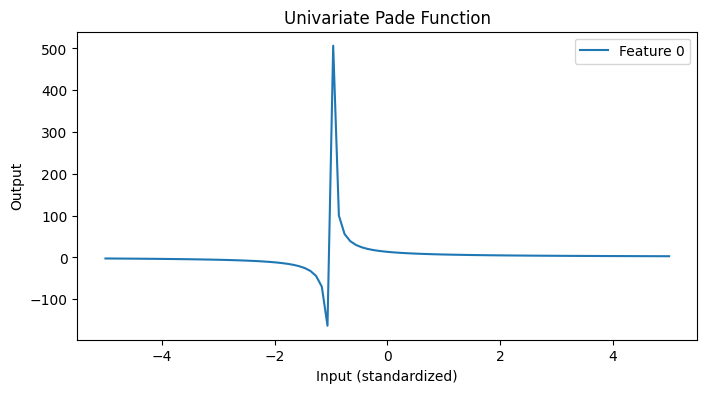

In [52]:
import matplotlib.pyplot as plt

# Generate input values (standardized)
x = np.linspace(-5, 5, 100)

# Compute the univariate function
degree_p = best_params_CA["orders1_layer_1"]  # It should be changed based on the layer   [Layer#- - 1] /2
degree_q = best_params_CA["orders2_layer_1"]  # It should be changed based on the layer
y = pade_function(x, w_p, w_q, alpha_p, beta_p, zeta_p, alpha_q, beta_q, zeta_q, degree_p, degree_q)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='Feature 0')
plt.xlabel('Input (standardized)')
plt.ylabel('Output')
plt.title('Univariate Pade Function')
plt.legend()
plt.show()

In [41]:
# num_features = X_train.shape[1]

# for feature_idx in range(num_features):
#     # Extract parameters for feature i (requires modifying PadeRKAN to support per-feature parameters)
#     pade_layer = model.layers[5]  # Assuming the first PadeRKAN layer is used for feature-wise parameters
#     w_p_feature = pade_layer.w_p.detach().cpu().numpy()
#     w_q_feature = pade_layer.w_q.detach().cpu().numpy()
    
#     y = pade_function(x, w_p_feature, w_q_feature, alpha_p, beta_p, zeta_p, alpha_q, beta_q, zeta_q, degree_p, degree_q)
    
#     plt.figure(figsize=(8, 4))
#     plt.plot(x, y)
#     plt.title(f'Univariate Function for Feature {feature_idx}')
#     plt.xlabel('Input (standardized)')
#     plt.ylabel('Output')
#     plt.show()